In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load and view data
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Step 8: Select the important columns (Features)
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']

X = df[features]
y = df['SalePrice']

# Handle missing values if any
X = X.fillna(X.mean())

print("Data selection completed successfully!")

Data selection completed successfully!


In [5]:
# Step 9: Split the data and train the Linear Regression model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed successfully")

Model training completed successfully


In [7]:
# Step 10: Model Evaluation (Professional Version)
y_pred = model.predict(X_test)

# Calculate Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=========================================")
print("       MODEL EVALUATION REPORT           ")
print("=========================================")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R-squared Score (R2)           : {r2:.4f}")
print("=========================================")

       MODEL EVALUATION REPORT           
Root Mean Squared Error (RMSE) : 52975.7177
R-squared Score (R2)           : 0.6341


In [8]:
# Step 11: Create a DataFrame to compare actual and predicted prices
comparison_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

# Show the first 10 rows for submission report
print("=========================================")
# Display formatting
comparison_df['Actual Price'] = comparison_df['Actual Price'].map('${:,.2f}'.format)
comparison_df['Predicted Price'] = comparison_df['Predicted Price'].map('${:,.2f}'.format)

print(comparison_df.head(10).to_string(index=False))
print("=========================================")

Actual Price Predicted Price
 $154,500.00     $113,410.67
 $325,000.00     $305,081.88
 $115,000.00     $135,904.79
 $159,000.00     $205,424.68
 $315,500.00     $227,502.68
  $75,500.00     $121,157.48
 $311,500.00     $205,577.98
 $146,000.00     $183,787.20
  $84,500.00     $121,157.48
 $135,500.00     $147,219.22


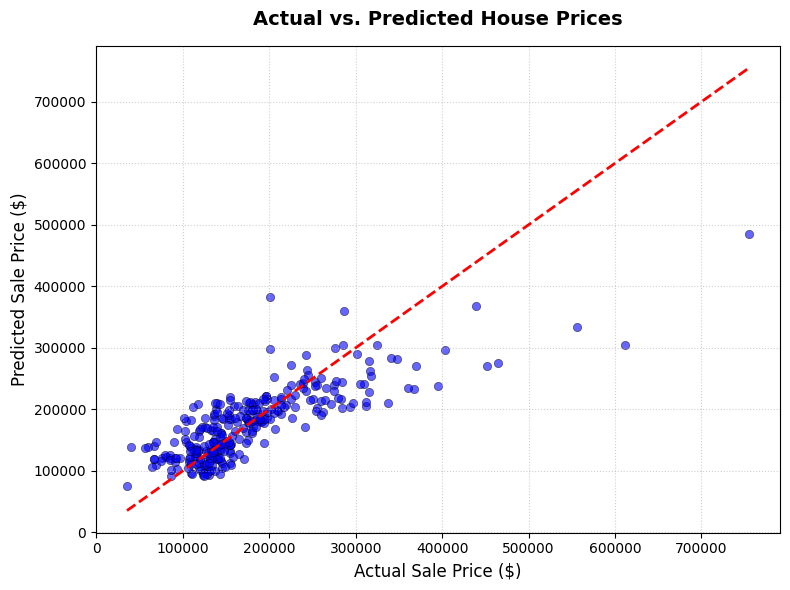

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 12: Professional Visualization for Internship Report
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue', edgecolor='k')

# Drawing the ideal reference line where Actual = Predicted
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Actual vs. Predicted House Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Tight layout for saving the image cleanly
plt.tight_layout()

# Save the plot as an image for the project documentation
plt.savefig('actual_vs_predicted_prices.png', dpi=300)
plt.show()

In [10]:
# Step 13: Feature Importance Analysis (Coefficients)
coefficients = model.coef_

importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient (Weight)': coefficients
})

# Sorting by importance
importance_df = importance_df.sort_values(by='Coefficient (Weight)', ascending=False)

print("=========================================")
print("       FEATURE IMPORTANCE REPORT         ")
print("=========================================")
print(importance_df.to_string(index=False))
print("=========================================")

       FEATURE IMPORTANCE REPORT         
     Feature  Coefficient (Weight)
    FullBath          30014.324109
   GrLivArea            104.026307
BedroomAbvGr         -26655.165357
